# Evaluation of saturating fate interactions and curvature targets

**Role:** Analysis.

Load completed models without fitting. Compare Gaussian activation families and the roles of size dependence and predicted-curvature propagation on exactly the same held-out organoids. Compare Gaussian-only, mean-only and jointly trained learned-saturation models separately for each prediction target. A saved zero-masking depth-2 FiLM supplies the Gaussian reference only; no mean-curvature FiLM is implied.

Physical residual predictions receive their own saved per-target baseline exactly once. All figures report equal-organoid errors; uncertainty conditions on fitted models. Regional categories are reconstructed from source geometry, never from another experiment. Neither anatomical labels nor observed neighboring curvatures enter prediction. Coefficient plots show every ordered marker pair, including Unassigned, and distinguish fixed low-support saturation values from fitted ones. The decomposition is reference-dependent and not causal.

Source targets are area-weighted cell-patch averages of signed H=(k1+k2)/2 and K=k1*k2. Therefore H²−K is a descriptive diagnostic: the pointwise inequality need not survive patch averaging or target cleanup. We do not impose it on training.

In [1]:
from pathlib import Path
import sys
from IPython import get_ipython
PROJECT_ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p/'src/models/gnn.py').is_file())  # Repository root.
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
import copy
import gc
import hashlib
import itertools
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from IPython.display import display, Image
from src.artifacts.runs import AnalysisRun
from src.artifacts.bundle import save_bundle, load_bundle, graph_membership
from src.artifacts.paths import training_run_path
from src.artifacts.provenance import workflow_fingerprint
from src.training.preparation import physical_fate_fold, prepare_fold, combine_target_folds
from src.training.coupled_fit import graph_samples
from src.analysis.metrics.evaluation import prediction_table
from src.analysis.spatial.regions import graph_regions
from src.data.preprocessing import interpolate_target_outliers_from_neighbors
from src.models.coupled_fate import normalized_tanh, neighbor_average_matrix
from src.data.neighborhood_counts import exact_hop_counts, fate_identities
if get_ipython() is not None:
    get_ipython().run_line_magic('matplotlib', 'inline')
torch.set_num_threads(4)

## Analysis settings
Choose the completed run and coefficient readout before loading data. All saved folds are evaluated; the chosen fold affects only coefficient figures.

In [2]:
# Saved models and outputs
TRAINING_RUN = 'activation_curvatures_20260928_170831'  # Completed run under training_results/coupled_fate_training.
REFERENCE_MODEL = 'film'  # Existing Gaussian accuracy reference.
REFERENCE_DEPTH = 2  # Saved FiLM depth; coupled propagation is not restricted to this radius.
REFERENCE_WIDTH = 128  # Saved FiLM hidden width.
REFERENCE_SEED = 42  # Saved reference training seed.
REFERENCE_RATE = 0.0  # Intact zero-masking reference.
OUTPUT_TAG = 'response_curvatures'  # Evaluation directory inside the selected run.

# Coefficient figures
READOUT_TARGET_SET = 'gaussian'  # Select gaussian, mean or joint for the all-pair figures.
READOUT_COUPLING = True  # Coupled or local learned-saturation model.
READOUT_FOLD = 0  # One explicit coefficient reference convention; all folds are exported.
N_POINTS = 50  # Curve resolution inside each fold's training range.
MIN_DISPLAY_ORGANOIDS = 20  # Flag sparse pair support in plots.

# Anatomical and uncertainty settings
REGION_SETTINGS = dict(
    crypt_max=.8,  # End of profile-qualified crypt interiors.
    neck_max=1.2,  # End of qualified neck regions; remaining qualified cells are villus.
)
BOOTSTRAP_DRAWS = 2000  # Paired organoid bootstrap draws for model comparisons.
BOOTSTRAP_SEED = 42  # Repeatable conditional uncertainty estimates.

## Restore saved artifacts
Verify complete outer-fold coverage and resolve the original Gaussian FiLM reference. All predictions use stored preprocessing and baseline offsets.

In [3]:
run = AnalysisRun(PROJECT_ROOT/'training_results/coupled_fate_training'/TRAINING_RUN)
if not (run.directory/'complete.json').exists():raise ValueError('Training run is not complete.')
reference = AnalysisRun(run.settings['reference_run'])
membership = json.loads((run.directory/'splits.json').read_text())
if membership!=json.loads((reference.directory/'splits.json').read_text()):raise ValueError('Different outer folds.')
records = run.records
for name,rows in records.groupby('name'):
    if set(rows.fold)!={s['fold'] for s in membership}:raise ValueError(f'Missing folds for {name}')
OUTPUT_DIR = run.directory/'analysis'/OUTPUT_TAG
OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
(OUTPUT_DIR/'predictions').mkdir(exist_ok=True)
settings = dict(training_run=str(run.directory),reference_run=str(reference.directory),readout_target=READOUT_TARGET_SET,
    code_sha256=workflow_fingerprint(PROJECT_ROOT/'experiments/benchmarks/coupled_fate_evaluation.ipynb'),
    catalog_sha256=hashlib.sha256((run.directory/'models.json').read_bytes()).hexdigest(),readout_coupling=READOUT_COUPLING,readout_fold=READOUT_FOLD,region_settings=REGION_SETTINGS,bootstrap_draws=BOOTSTRAP_DRAWS)
(OUTPUT_DIR/'settings.json').write_text(json.dumps(settings,indent=2))
raw = load_bundle(run.directory/'cohort')['raw_graphs']
identity_names = load_bundle(run.directory/'cohort')['all_marker_names']+['Unassigned']
print('Loaded',len(records),'saved models; targets:',run.settings['target_sets'])

Loaded 120 saved models; targets: {'gaussian': [0], 'mean': [1], 'joint': [0, 1]}


## Held-out predictions and regions
Evaluate each target in physical units, check Gaussian target equality against FiLM, and verify that cell-weighted regional errors reconstruct total MSE. Save node predictions and organoid-level scores.

In [4]:
scores=[];geometry=[];audits=[];support=[]
for split in membership:
    fold=split['fold'];annotations={};cache={}
    for oid in split['validation']:
        table=graph_regions(raw[oid],PROJECT_ROOT/'training_data'/run.settings['dataset'],**REGION_SETTINGS)
        annotations[oid]=table.region.to_numpy()
        support.extend(dict(organoid_str=oid,region=r,n_cells=int(n)) for r,n in table.region.value_counts().items())
    ref_rows=reference.records[(reference.records.name==REFERENCE_MODEL)&(reference.records.depth==REFERENCE_DEPTH)&
        (reference.records.hidden_dim==REFERENCE_WIDTH)&(reference.records.seed==REFERENCE_SEED)&(reference.records.rate==REFERENCE_RATE)&(reference.records.fold==fold)]
    if len(ref_rows)!=1:raise ValueError('Ambiguous FiLM checkpoint.')
    selected=reference.select(ref_rows.iloc[0].key)
    film=prediction_table(selected,device='cpu',batch_size=4)
    for oid,g in film.groupby('organoid_str',sort=False):
        g=g.sort_values('node');regions=annotations[oid]
        cache[oid]=(g.y_true.to_numpy(),g.y_pred.to_numpy())
        for region in ['total',*np.unique(regions)]:
            take=np.ones(len(g),bool) if region=='total' else regions==region
            scores.append(dict(name='FiLM',fold=fold,target=0,organoid_str=oid,n_cells=len(g),region=region,
                mse=float(np.mean((g.y_pred.to_numpy()[take]-g.y_true.to_numpy()[take])**2))))
    for target_set in run.settings['target_sets']:
        prepared=load_bundle(run.directory/f'inputs/fold_{fold}_{target_set}')
        samples=[]
        for g in prepared['groups']['val']:
            single=copy.deepcopy(g);single.y=g.y[:,0]
            s=graph_samples([single],run.settings['pair_radius'])[0];s['y']=g.y.numpy();samples.append(s)
        for row in records[(records.fold==fold)&(records.target_set==target_set)].itertuples():
            model=load_bundle(run.directory/row.bundle)['model'];saved=[];truths=[];offsets=[0];ids=[]
            for sample in samples:
                oid=sample['organoid_str'];baseline=np.asarray(prepared['baseline_offsets'][oid]);truth=sample['y']+baseline
                prediction=model.predict_sample({k:v for k,v in sample.items() if k!='y'})+baseline
                if 0 in row.target_indices:
                    j=row.target_indices.index(0)
                    if not np.allclose(truth[:,j],cache[oid][0],rtol=2e-6,atol=1e-8):raise ValueError('Gaussian targets do not match FiLM.')
                regions=annotations[oid]
                for j,target in enumerate(row.target_indices):
                    error=(prediction[:,j]-truth[:,j])**2;reconstruction=0.
                    for region in ['total',*np.unique(regions)]:
                        take=np.ones(len(error),bool) if region=='total' else regions==region
                        mse=float(error[take].mean())
                        scores.append(dict(name=row.name,fold=fold,target=target,organoid_str=oid,n_cells=sample['N'],region=region,mse=mse,
                            baseline_mse=float(np.mean(sample['y'][take,j]**2))))
                        if region!='total':reconstruction+=mse*take.sum()/len(error)
                    if not np.isclose(reconstruction,error.mean()):raise ValueError('Regional reconstruction failed.')
                if len(row.target_indices)==2:
                    for kind,values in [('prediction',prediction),('target',truth)]:
                        gap=values[:,1]**2-values[:,0]
                        geometry.append(dict(name=row.name,fold=fold,organoid_str=oid,kind=kind,fraction_below_zero=float(np.mean(gap<0)),mean_gap=float(gap.mean())))
                saved.append(prediction);truths.append(truth);ids.append(oid);offsets.append(offsets[-1]+len(prediction))
            np.savez_compressed(OUTPUT_DIR/'predictions'/f'{row.key}.npz',prediction=np.concatenate(saved),truth=np.concatenate(truths),offsets=offsets,organoid_ids=np.asarray(ids),target_indices=row.target_indices)
            audits.append(dict(key=row.key,fold=fold,matched_targets=True,regions_reconstruct_total=True))
            print('Evaluated',row.key,flush=True)
        del prepared,samples
        gc.collect()
scores=pd.DataFrame(scores);scores.to_csv(OUTPUT_DIR/'validation_mse.csv',index=False)
pd.DataFrame(support).drop_duplicates().to_csv(OUTPUT_DIR/'regional_support.csv',index=False)
pd.DataFrame(geometry).to_csv(OUTPUT_DIR/'patch_curvature_diagnostic.csv',index=False)
(OUTPUT_DIR/'comparison_audit.json').write_text(json.dumps(audits,indent=2))
summary=scores.groupby(['name','target','region']).mse.agg(['mean','sem','count']).reset_index()
summary.to_csv(OUTPUT_DIR/'mse_summary.csv',index=False)

Evaluated gaussian_center_constant_local_f0_s42


Evaluated gaussian_center_constant_coupled_f0_s42


Evaluated gaussian_center_N_local_f0_s42


Evaluated gaussian_center_N_coupled_f0_s42


Evaluated gaussian_linear_constant_local_f0_s42


...

Evaluated mean_learned_N_local_f4_s42


Evaluated joint_learned_constant_coupled_f4_s42


Evaluated joint_learned_N_coupled_f4_s42


Evaluated joint_learned_N_local_f4_s42


Evaluated joint_learned_constant_local_f4_s42


## Activation and joint-target accuracy
Compare model families on Gaussian curvature, then separate versus joint training on each output. Shaded intervals are one organoid SEM. Paired bootstrap intervals condition on the fitted models and do not include retraining uncertainty.

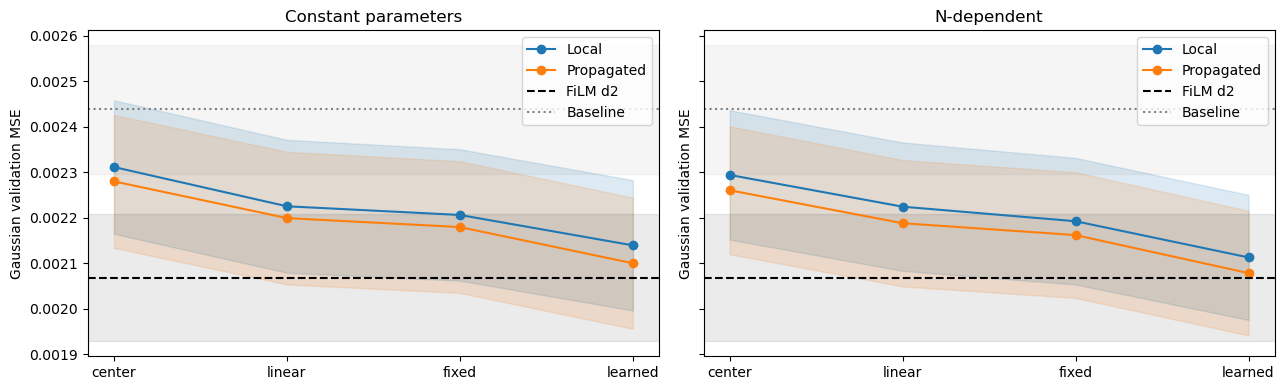

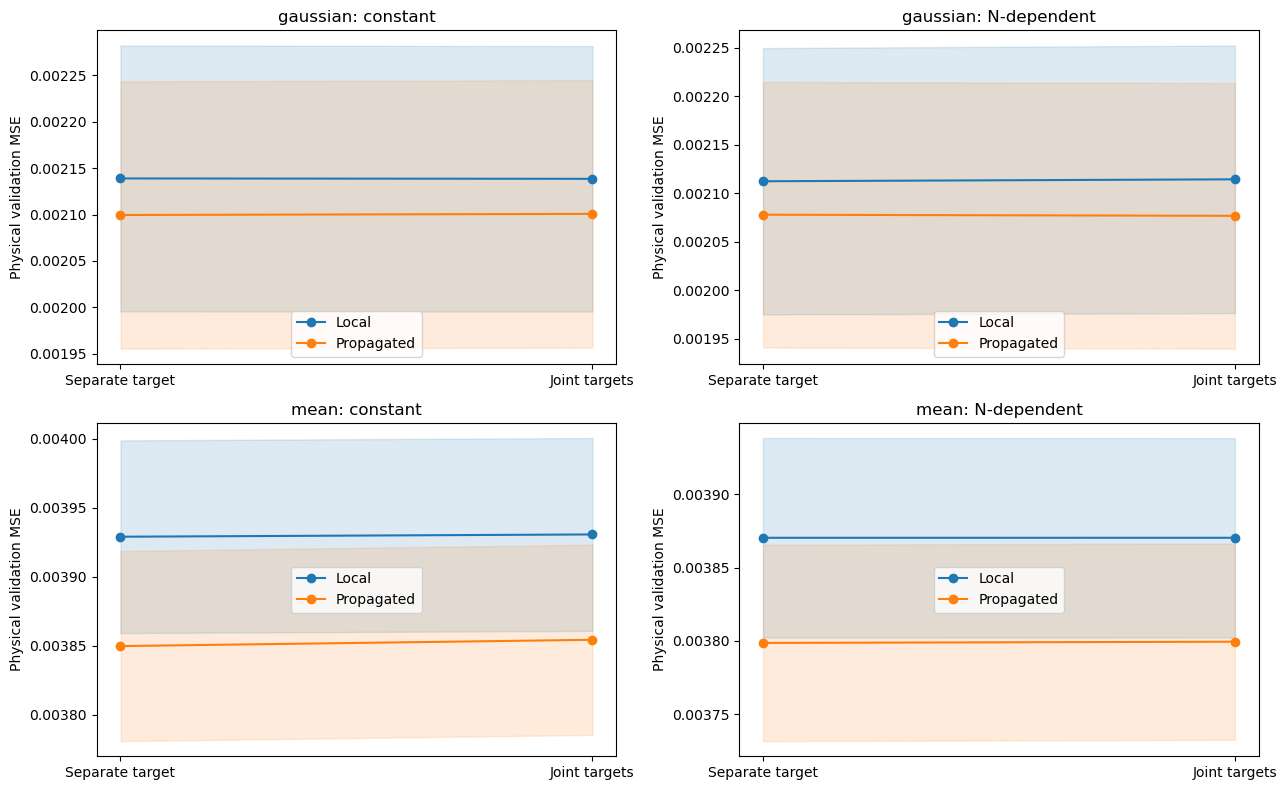

In [5]:
families=['center','linear','fixed','learned']
fig,axes=plt.subplots(1,2,figsize=(13,4),sharey=True)
for ax,dep in zip(axes,[False,True]):
    for coupling,label in [(False,'Local'),(True,'Propagated')]:
        names=[f'gaussian_{f}_{"N" if dep else "constant"}_{"coupled" if coupling else "local"}' for f in families]
        part=summary[(summary.target==0)&(summary.region=='total')].set_index('name').reindex(names)
        x=np.arange(len(names));line,=ax.plot(x,part['mean'],marker='o',label=label)
        ax.fill_between(x,part['mean']-part['sem'],part['mean']+part['sem'],color=line.get_color(),alpha=.15)
    film=summary[(summary.name=='FiLM')&(summary.region=='total')].iloc[0]
    ax.axhline(film['mean'],color='black',ls='--',label='FiLM d2');ax.axhspan(film['mean']-film['sem'],film['mean']+film['sem'],color='black',alpha=.08)
    base=scores[(scores.name=='gaussian_center_constant_local')&(scores.region=='total')].baseline_mse
    ax.axhline(base.mean(),color='gray',ls=':',label='Baseline');ax.axhspan(base.mean()-base.sem(),base.mean()+base.sem(),color='gray',alpha=.08)
    ax.set_xticks(x,families);ax.set(title='N-dependent' if dep else 'Constant parameters',ylabel='Gaussian validation MSE');ax.legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'gaussian_activation_comparison.png',dpi=160);plt.show()

fig,axes=plt.subplots(2,2,figsize=(13,8))
for target in [0,1]:
    for dep in [False,True]:
        ax=axes[target,int(dep)];individual=['gaussian','mean'][target]
        for coupling,label in [(False,'Local'),(True,'Propagated')]:
            names=[f'{t}_learned_{"N" if dep else "constant"}_{"coupled" if coupling else "local"}' for t in [individual,'joint']]
            part=summary[(summary.target==target)&(summary.region=='total')].set_index('name').reindex(names)
            x=np.arange(2);line,=ax.plot(x,part['mean'],marker='o',label=label)
            ax.fill_between(x,part['mean']-part['sem'],part['mean']+part['sem'],alpha=.15,color=line.get_color())
        ax.set_xticks(x,['Separate target','Joint targets']);ax.set(title=f'{individual}: {"N-dependent" if dep else "constant"}',ylabel='Physical validation MSE');ax.legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'separate_vs_joint.png',dpi=160);plt.show()

# Paired differences use the same held-out organoids, not independent error bars.
rng=np.random.default_rng(BOOTSTRAP_SEED);paired=[]
for target in [0,1]:
    wide=scores[(scores.target==target)&(scores.region=='total')].pivot(index='organoid_str',columns='name',values='mse')
    comparisons=[]
    if target==0:
        comparisons.extend((name,'FiLM') for name in wide if name!='FiLM')
        for dep in ['constant','N']:
            for coupling in ['local','coupled']:
                comparisons.extend((f'gaussian_{f}_{dep}_{coupling}',f'gaussian_linear_{dep}_{coupling}') for f in ['fixed','learned'])
    for dep in ['constant','N']:
        for coupling in ['local','coupled']:
            comparisons.append((f'joint_learned_{dep}_{coupling}',f'{["gaussian","mean"][target]}_learned_{dep}_{coupling}'))
    for name in wide.columns:
        if name.endswith('_coupled') and name[:-8]+'_local' in wide:
            comparisons.append((name,name[:-8]+'_local'))
        if '_N_' in name and name.replace('_N_','_constant_') in wide:
            comparisons.append((name,name.replace('_N_','_constant_')))
        if '_learned_' in name and name.replace('_learned_','_fixed_') in wide:
            comparisons.append((name,name.replace('_learned_','_fixed_')))
    for a,b in dict.fromkeys(comparisons):
        d=(wide[a]-wide[b]).dropna().to_numpy()
        draws=np.concatenate([d[rng.integers(len(d),size=(min(100,BOOTSTRAP_DRAWS-i),len(d)))].mean(axis=1) for i in range(0,BOOTSTRAP_DRAWS,100)])
        lo,hi=np.quantile(draws,[.025,.975]);paired.append(dict(target=target,model=a,reference=b,difference=d.mean(),ci_low=lo,ci_high=hi,n_organoids=len(d)))
pd.DataFrame(paired).to_csv(OUTPUT_DIR/'paired_comparisons.csv',index=False)

## Regional and size-dependent errors
Regional panels include all observed annotation categories. Different regions can contain different organoid subsets. Common size bins enable matched N-dependent accuracy comparisons.

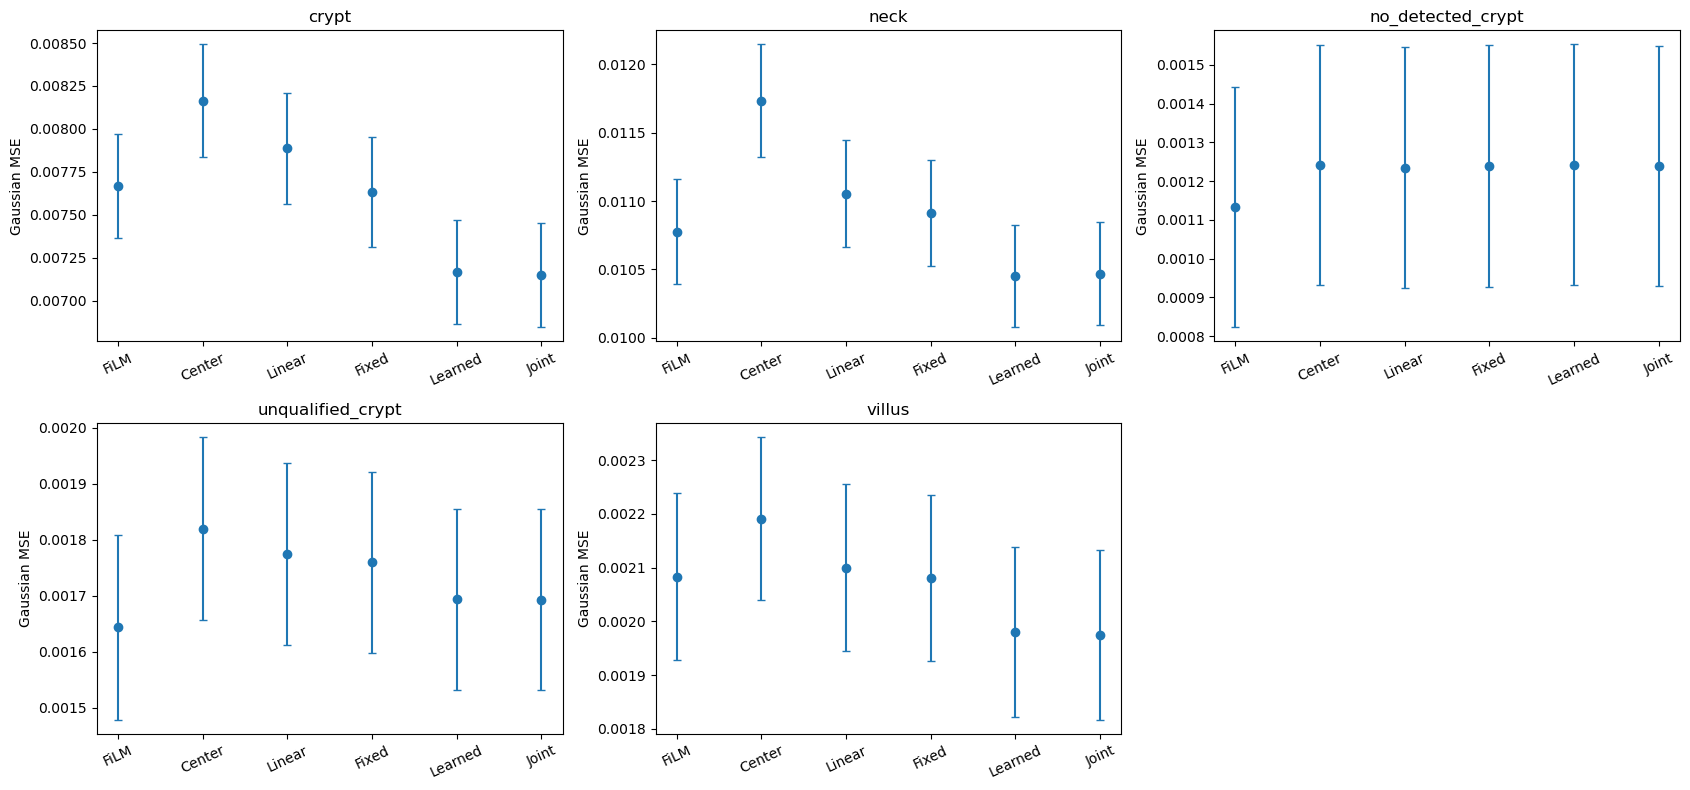

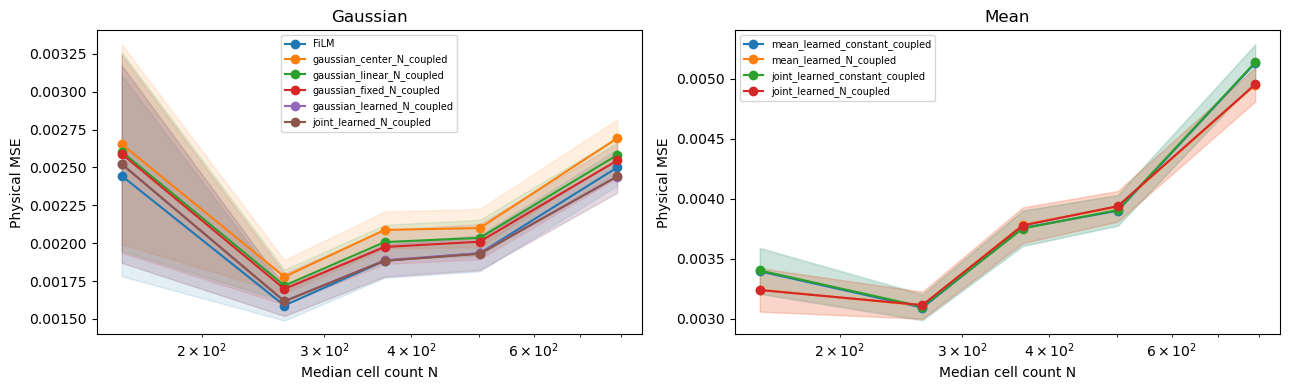

In [6]:
selected_names=['FiLM','gaussian_center_N_coupled','gaussian_linear_N_coupled','gaussian_fixed_N_coupled','gaussian_learned_N_coupled','joint_learned_N_coupled']
regions=[r for r in summary.region.unique() if r!='total']
fig,axes=plt.subplots(2,3,figsize=(17,8),squeeze=False)
for ax,region in zip(axes.flat,regions):
    part=summary[(summary.target==0)&(summary.region==region)].set_index('name').reindex(selected_names)
    ax.errorbar(np.arange(len(part)),part['mean'],yerr=part['sem'],fmt='o',capsize=3)
    ax.set_xticks(np.arange(len(part)),['FiLM','Center','Linear','Fixed','Learned','Joint'],rotation=25)
    ax.set(title=region,ylabel='Gaussian MSE')
for ax in list(axes.flat)[len(regions):]:ax.axis('off')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'mse_by_region.png',dpi=160);plt.show()

total=scores[scores.region=='total'].copy();sizes=total.drop_duplicates('organoid_str').n_cells
edges=np.unique(np.quantile(sizes,[0,.2,.4,.6,.8,1]));total['size_bin']=pd.cut(total.n_cells,edges,include_lowest=True,labels=False)
size_summary=total.groupby(['name','target','size_bin']).agg(mean=('mse','mean'),sem=('mse','sem'),N=('n_cells','median')).reset_index()
size_summary.to_csv(OUTPUT_DIR/'mse_by_size.csv',index=False)
fig,axes=plt.subplots(1,2,figsize=(13,4))
for target,ax in enumerate(axes):
    names=selected_names if target==0 else ['mean_learned_constant_coupled','mean_learned_N_coupled','joint_learned_constant_coupled','joint_learned_N_coupled']
    for name in names:
        part=size_summary[(size_summary.name==name)&(size_summary.target==target)]
        line,=ax.plot(part.N,part['mean'],marker='o',label=name)
        ax.fill_between(part.N,part['mean']-part['sem'],part['mean']+part['sem'],color=line.get_color(),alpha=.12)
    ax.set(xscale='log',xlabel='Median cell count N',ylabel='Physical MSE',title=['Gaussian','Mean'][target]);ax.legend(fontsize=7)
fig.tight_layout();fig.savefig(OUTPUT_DIR/'mse_by_size.png',dpi=160);plt.show()

## Learned pair amplitudes, saturation and center preferences
Export coefficients from every learned model and fold. Plot all ordered pairs for the selected target set, coupling mode and fold, for both constant and N-dependent parameters. Saturation is constant across N. Crosses identify fixed low-support values; gray amplitude panels indicate sparse pair support. Amplitudes depend on the saved training reference convention, and weak effects can leave saturation poorly identified.

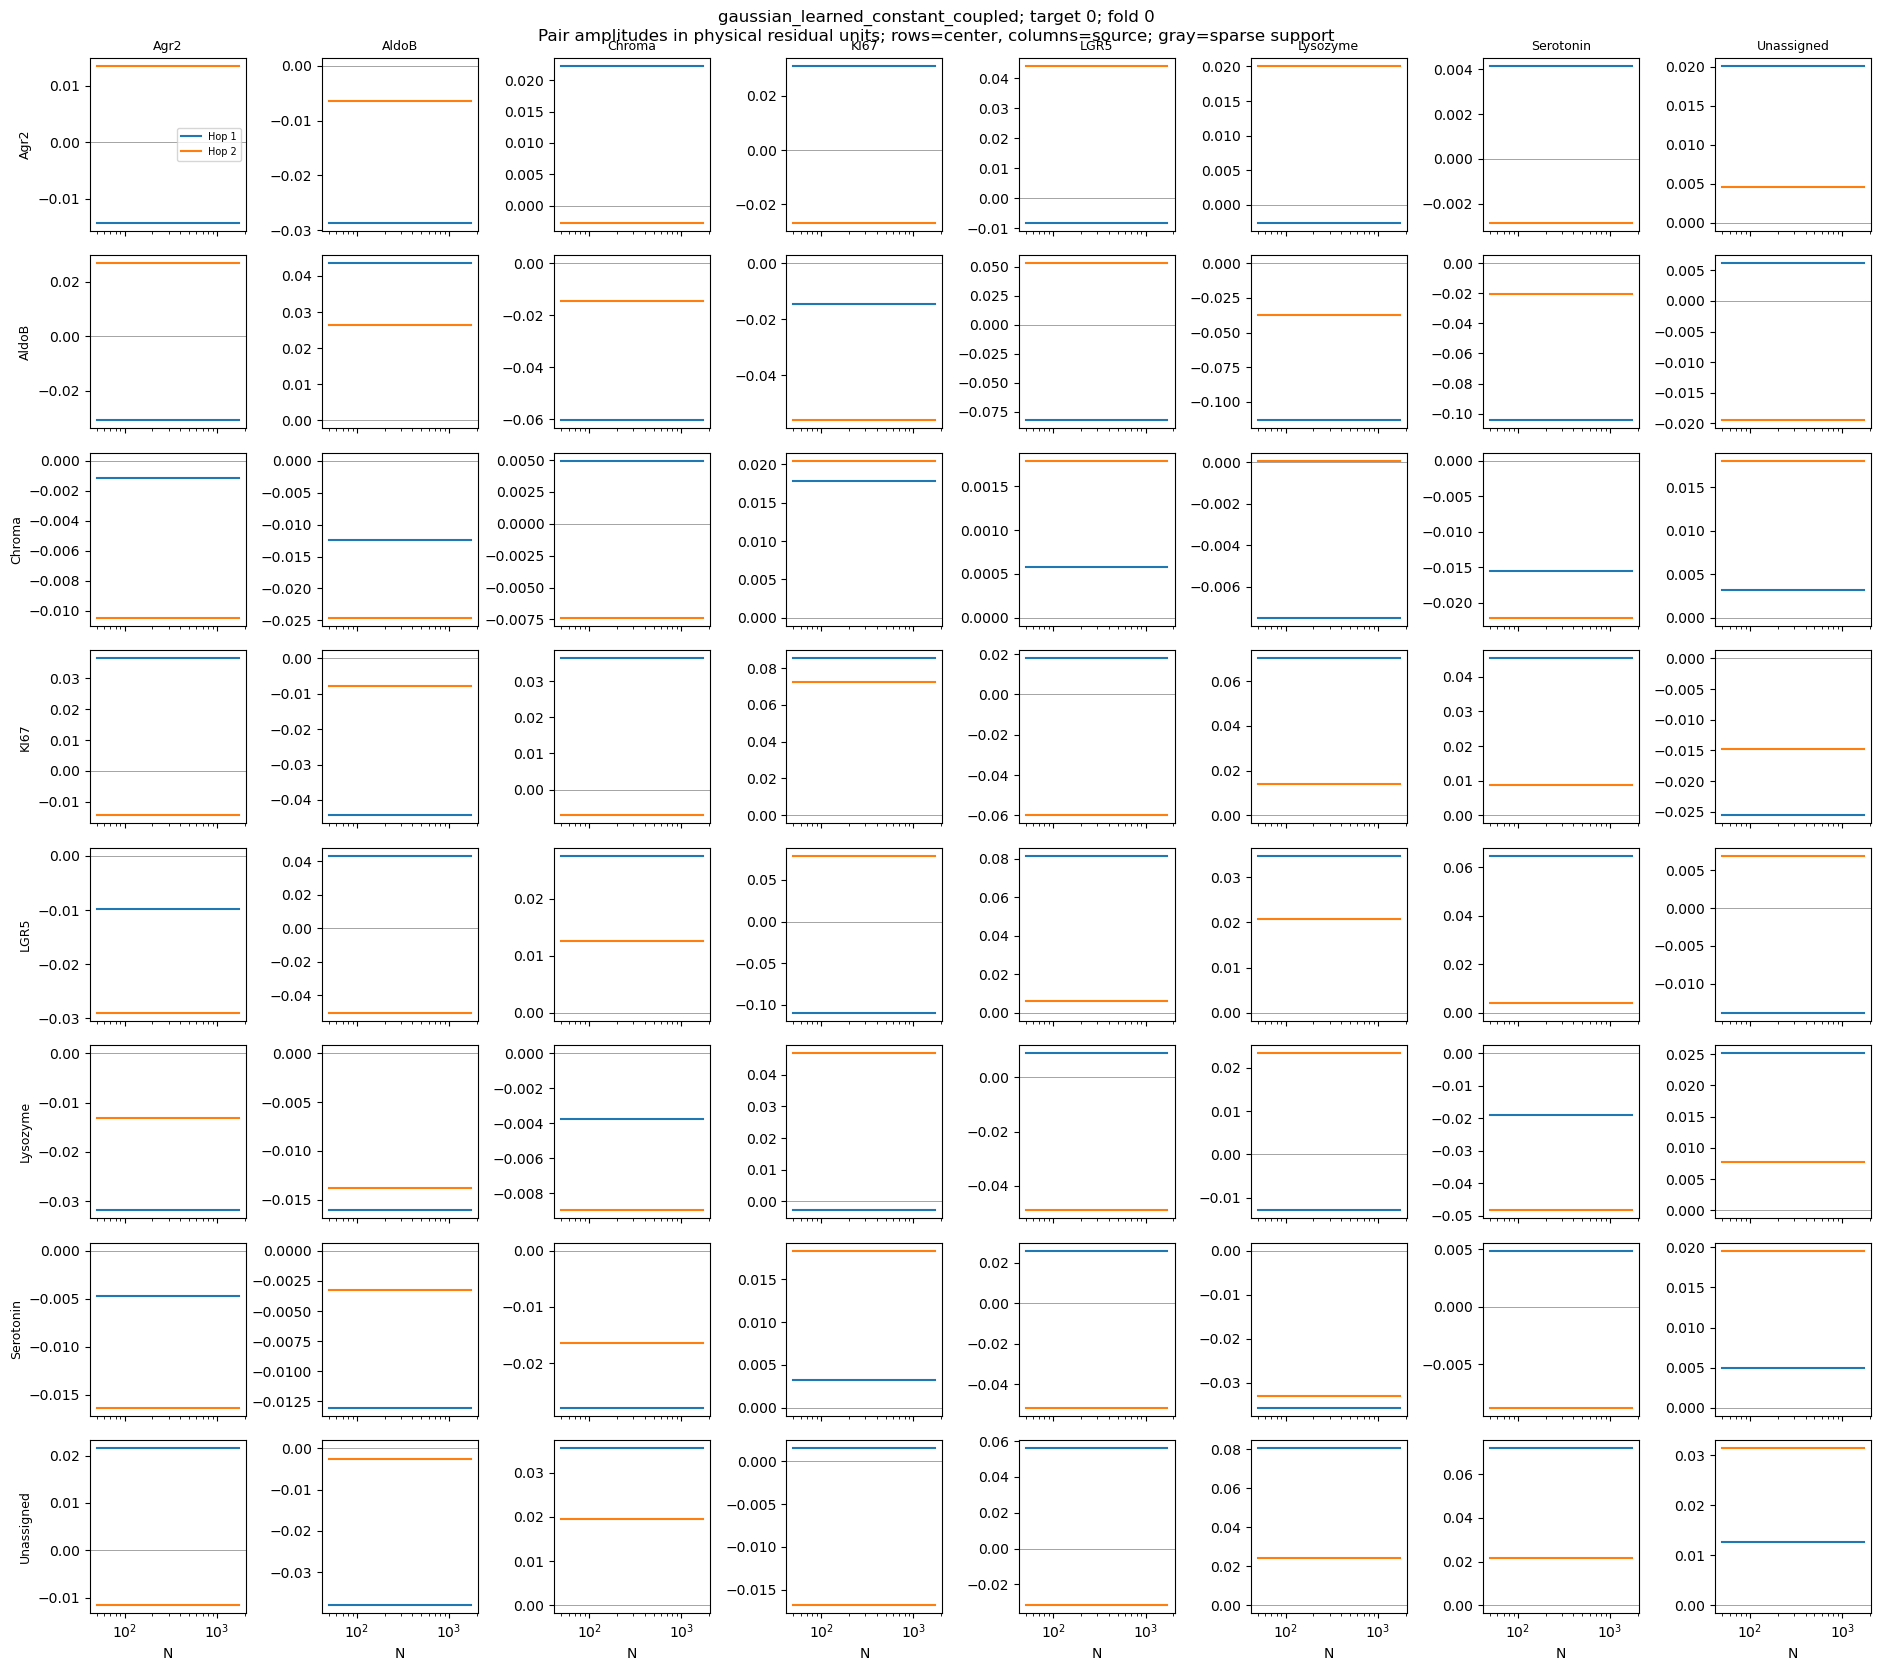

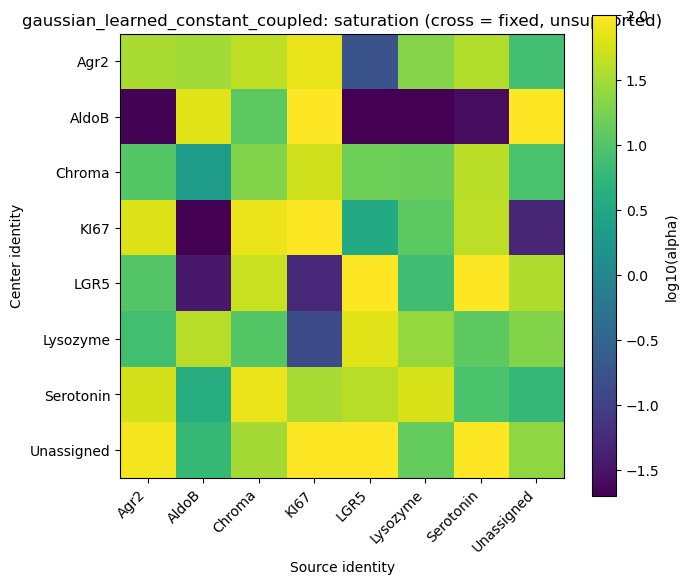

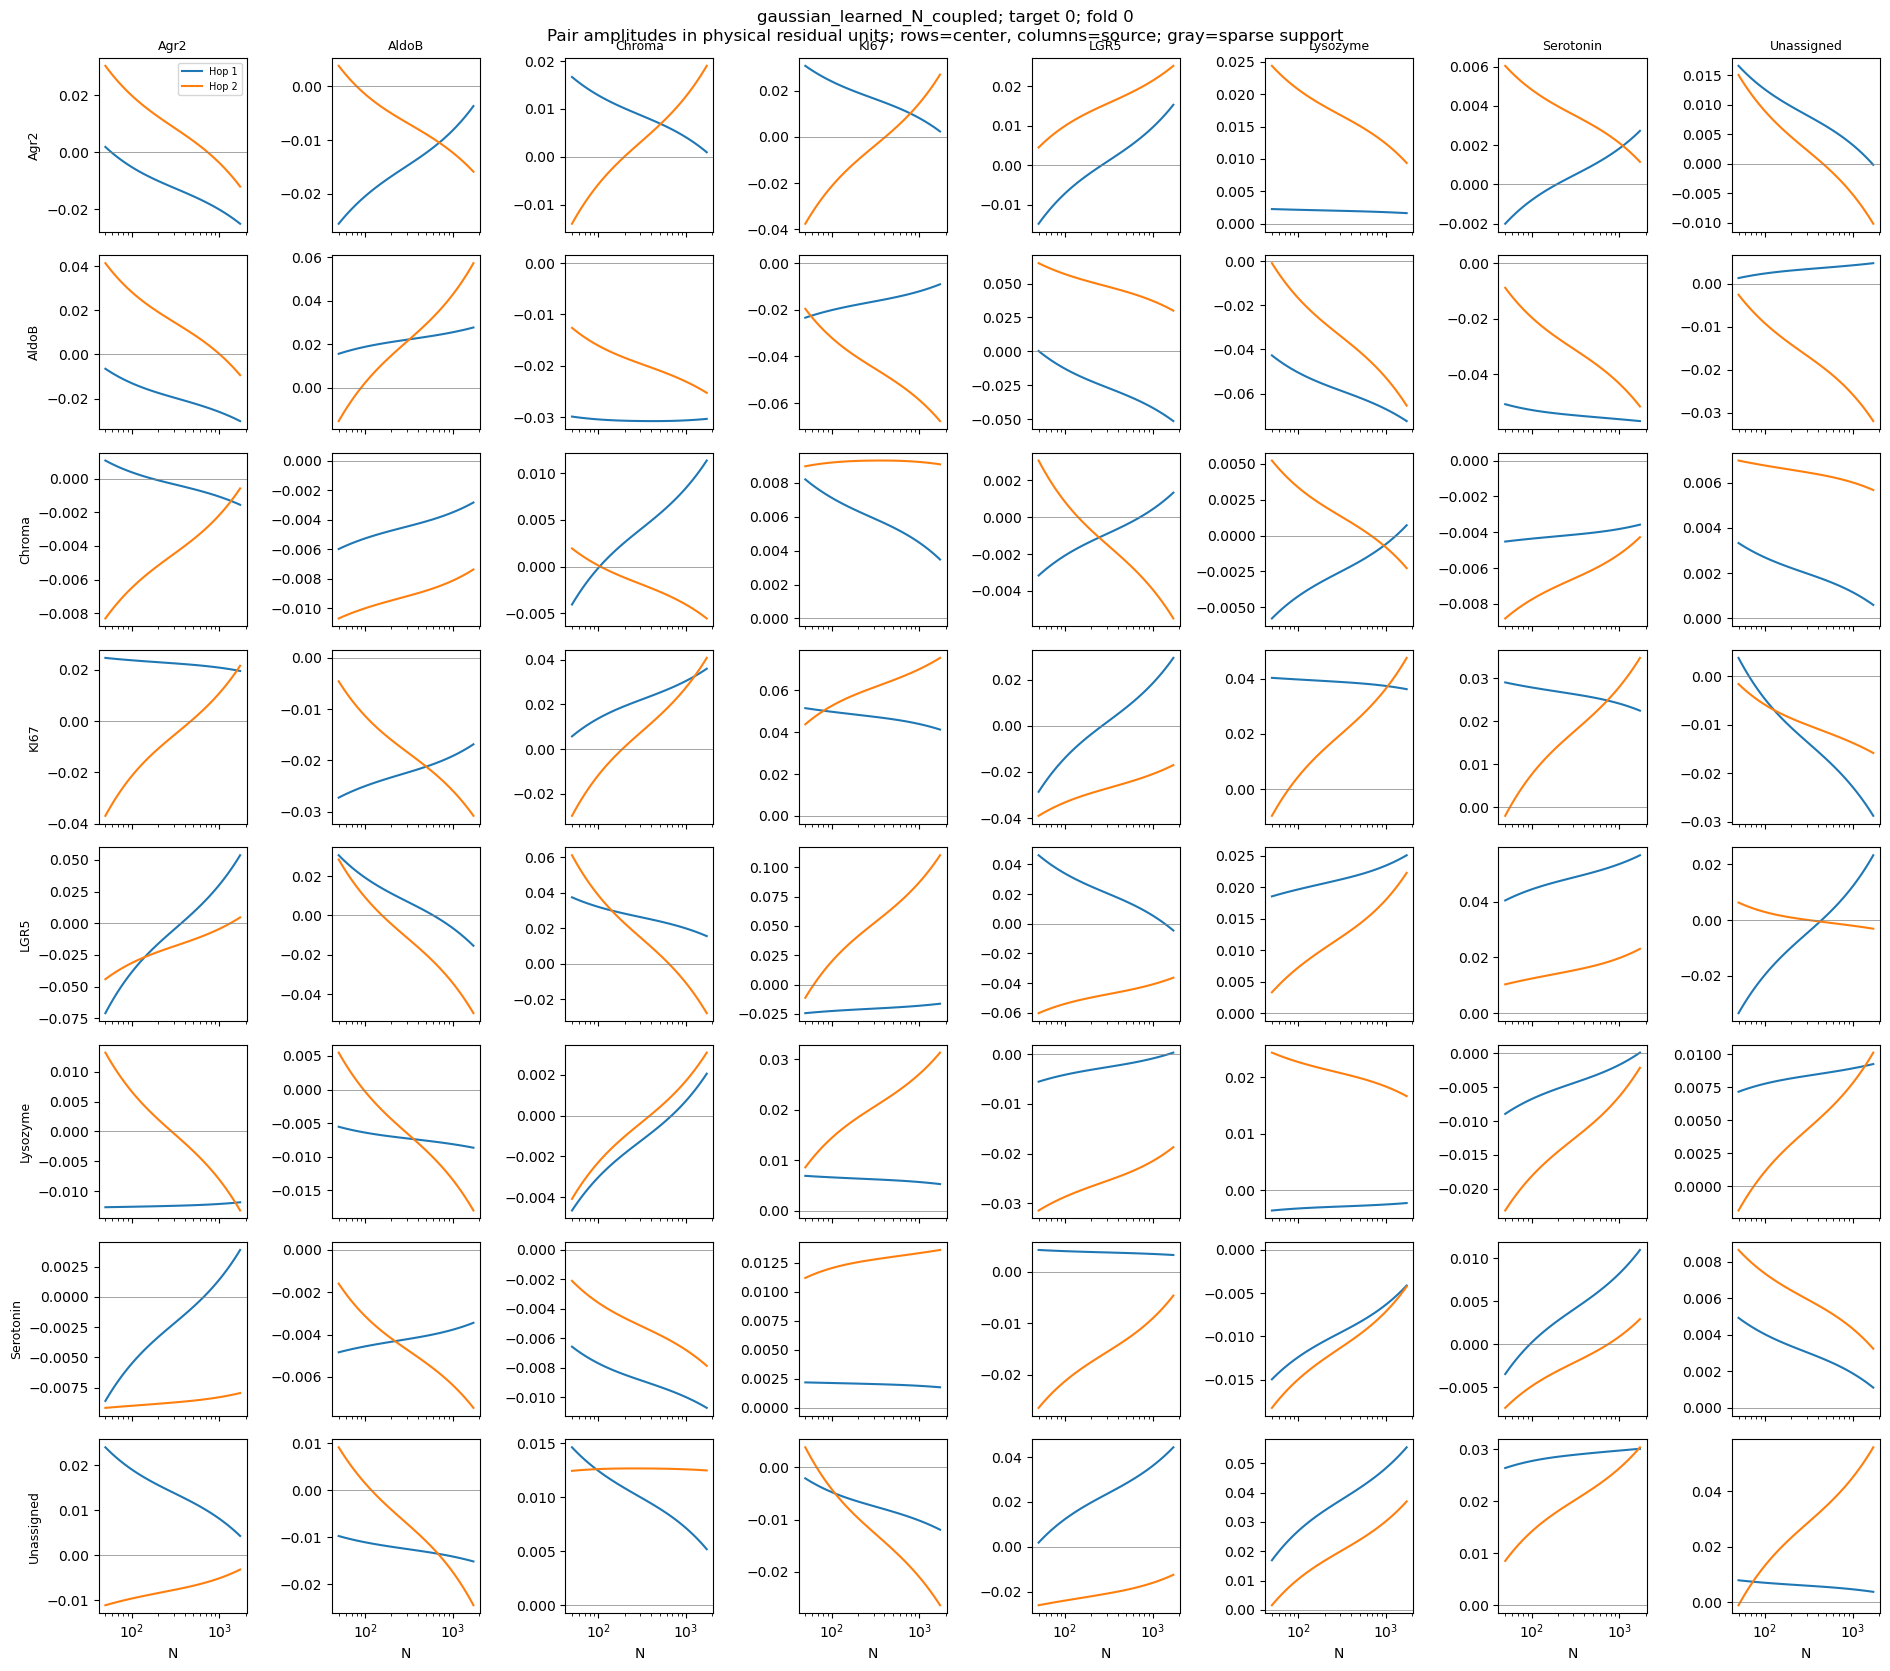

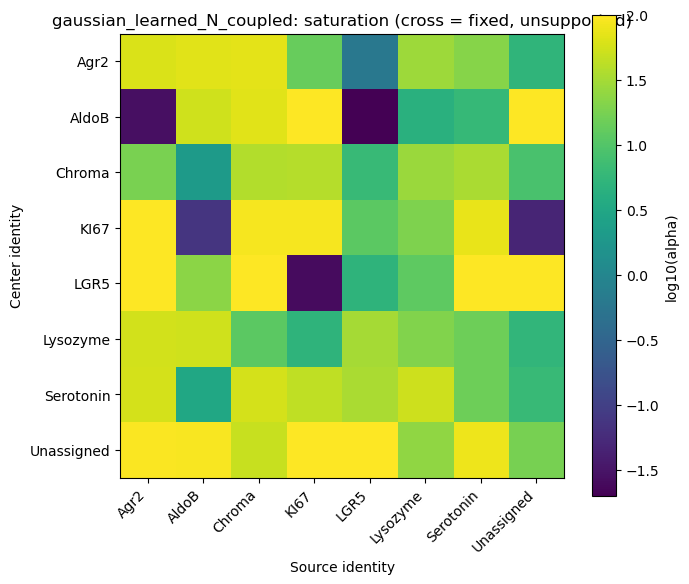

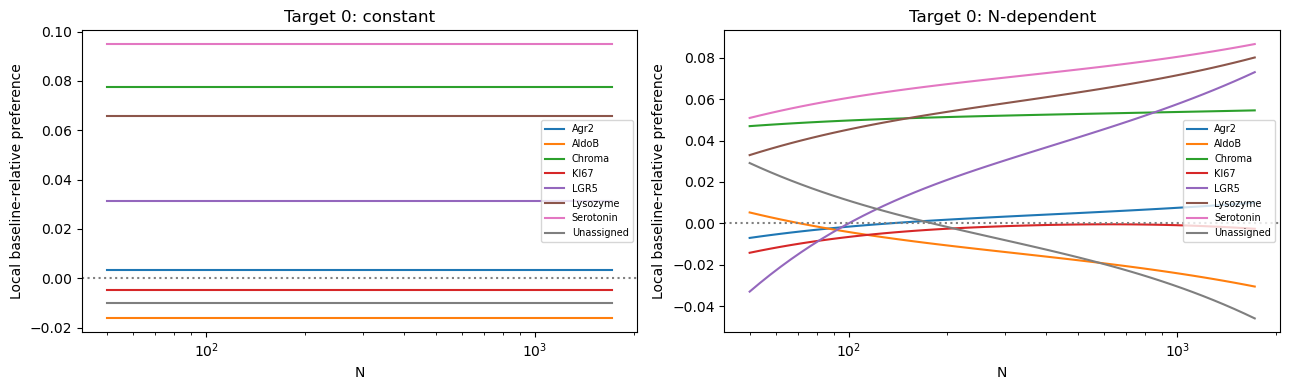

All-pair amplitudes, centers, coupling and saturation exported for every learned model/fold.


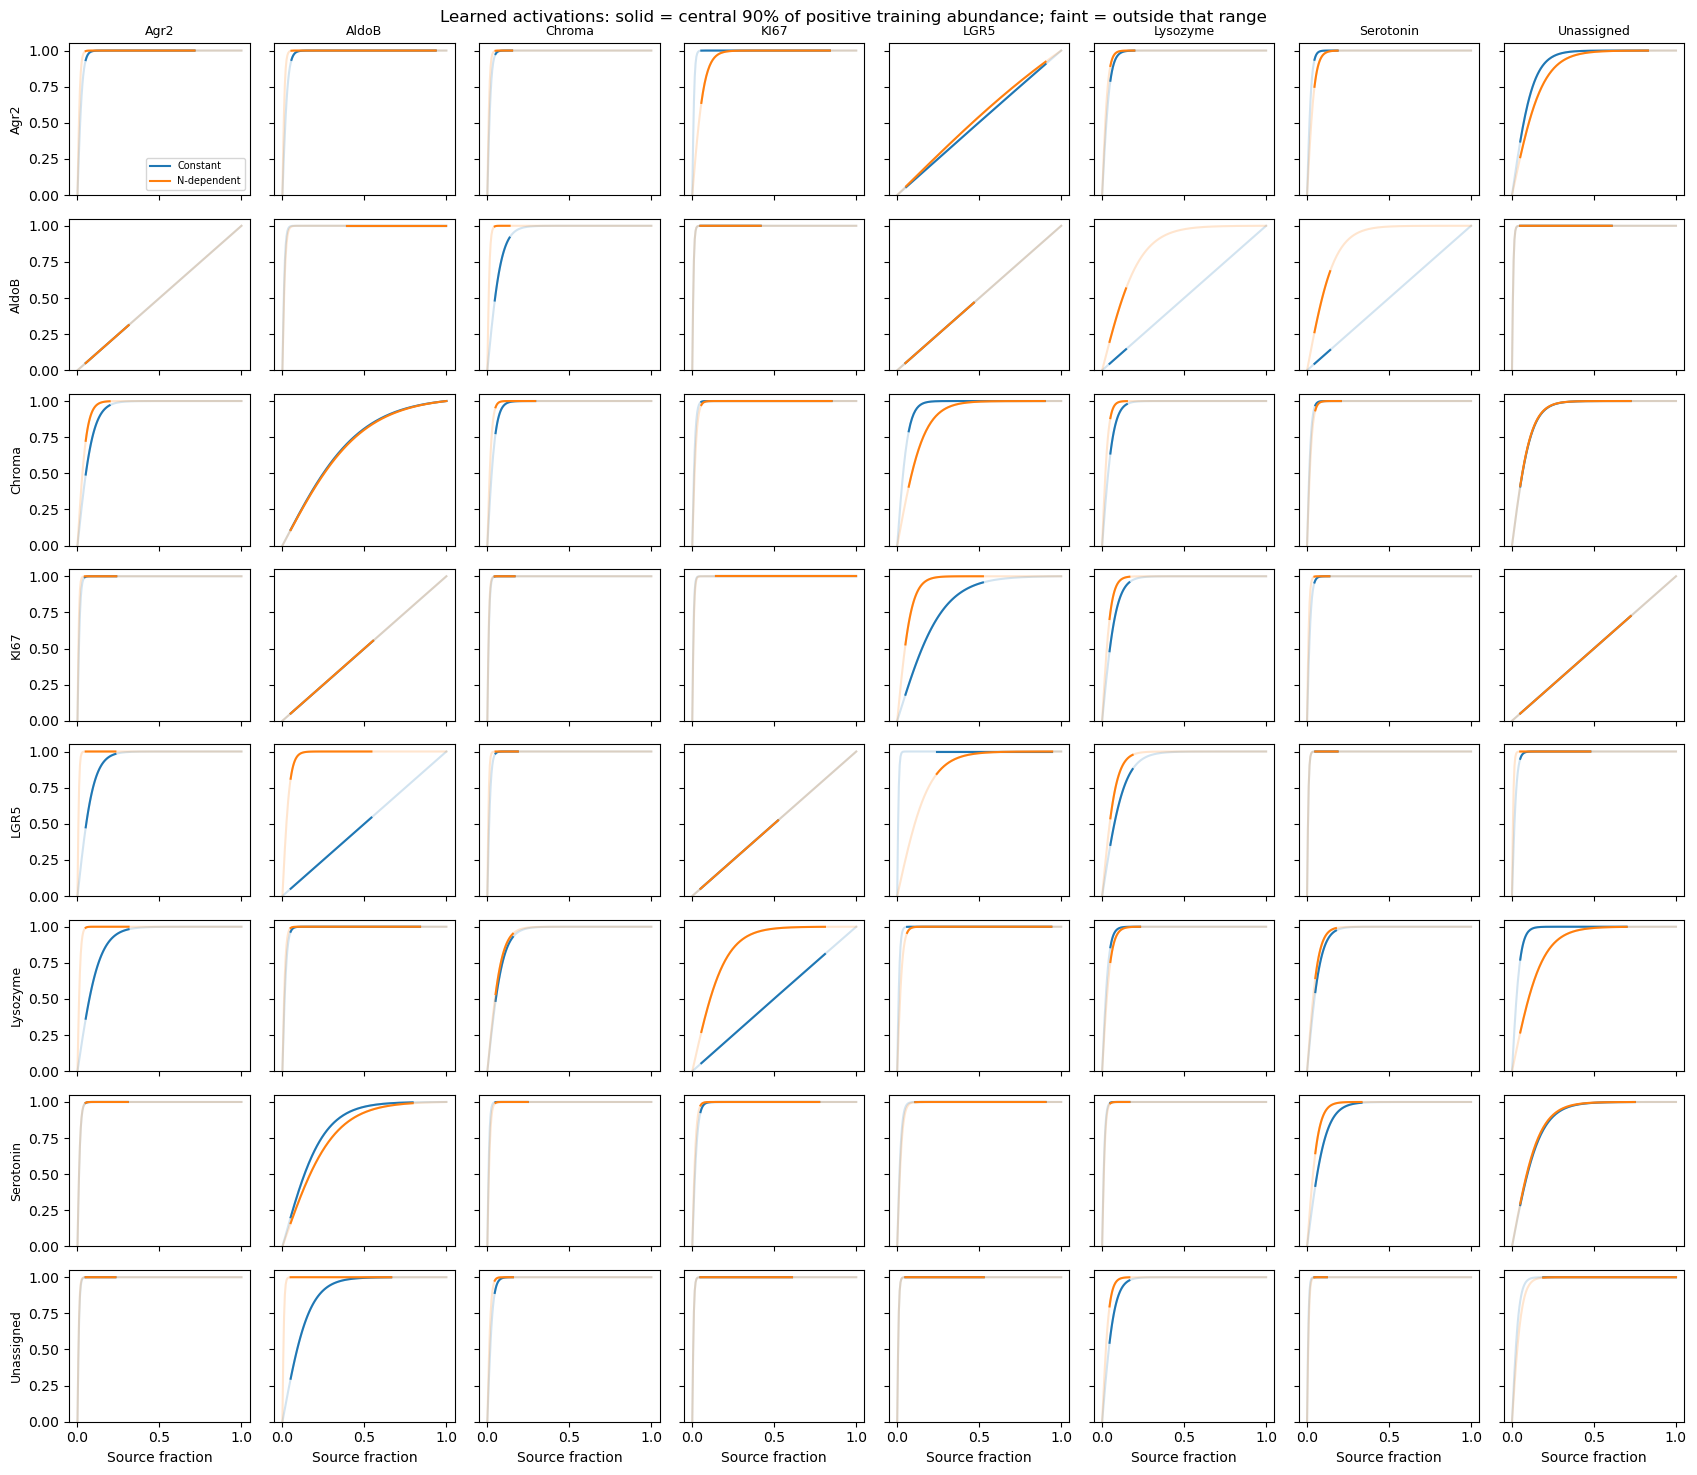

In [7]:
support_path=run.directory/'diagnostics/abundance_support.csv'
if support_path.exists():
    abundance_support=pd.read_csv(support_path)
else:
    rows=[]
    for fold in sorted(records.fold.unique()):
     data=load_bundle(run.directory/f'inputs/fold_{fold}_gaussian');names=data['marker_names']+['Unassigned'];t=len(names);values={(a,b):[] for a in range(t) for b in range(t)};support=np.zeros((t,t),int)
     for graph in data['groups']['train']:
      ids=fate_identities(graph.x);counts=exact_hop_counts(graph.x,graph.edge_index,2).sum(axis=1);population=counts.sum(axis=1,keepdims=True)
      fractions=np.divide(counts,population,out=np.zeros_like(counts,dtype=float),where=population>0)
      for a in np.unique(ids):
       for b in range(t):
        x=fractions[ids==a,b];values[a,b].append(x);support[a,b]+=int(np.any(x>0))
     for (a,b),pieces in values.items():
      x=np.concatenate(pieces) if pieces else np.array([]);positive=x[x>0]
      q=np.quantile(positive,[.05,.5,.95]) if len(positive) else [np.nan]*3
      rows.append(dict(fold=fold,center=names[a],source=names[b],n_centers=len(x),positive_centers=len(positive),organoid_support=int(support[a,b]),positive_fraction=float(np.mean(x>0)) if len(x) else 0.,positive_p05=q[0],positive_median=q[1],positive_p95=q[2]))
     print('Support fold',fold,flush=True)
    abundance_support=pd.DataFrame(rows)
abundance_support.to_csv(OUTPUT_DIR/'abundance_support.csv',index=False)

coefficient_rows=[];saturation_rows=[];center_rows=[];coupling_rows=[];models={}
for row in records[records.family=='learned'].itertuples():
    model=load_bundle(run.directory/row.bundle)['model']
    ns=np.geomspace(*np.exp(model.log_count_range.numpy()),N_POINTS)
    co=model.coefficients(ns)
    for a,center in enumerate(identity_names):
        for b,source in enumerate(identity_names):
            saturation_rows.append(dict(name=row.name,fold=row.fold,center=center,source=source,alpha=co['alpha'][a,b],
                fitted=bool(model.active_pairs[a,b]),support=int(model.pair_support[a,b])))
    for j,target in enumerate(row.target_indices):
        for index,n in enumerate(ns):
            coupling_rows.append(dict(name=row.name,fold=row.fold,target=target,N=n,gamma=co['gamma'][index,j]))
            for a,center in enumerate(identity_names):
                center_rows.append(dict(name=row.name,fold=row.fold,target=target,N=n,center=center,coefficient=co['a'][index,j,a]))
                for r in range(model.radius):
                    for b,source in enumerate(identity_names):
                        coefficient_rows.append(dict(name=row.name,fold=row.fold,target=target,N=n,center=center,source=source,hop=r+1,amplitude=co['P'][index,j,r,a,b]))
    if row.target_set==READOUT_TARGET_SET and row.coupling==READOUT_COUPLING and row.fold==READOUT_FOLD:
        models[row.size_dependent]=(model,row,ns,co)
for filename,rows in [('pair_amplitudes',coefficient_rows),('saturation',saturation_rows),('center_preferences',center_rows),('coupling',coupling_rows)]:
    pd.DataFrame(rows).to_csv(OUTPUT_DIR/f'{filename}.csv',index=False)

# Each pair panel shows both hops under one selected fold's coefficient convention.
for dep,(model,row,ns,co) in models.items():
    for j,target in enumerate(row.target_indices):
        t=len(identity_names);fig,axes=plt.subplots(t,t,figsize=(19,17),sharex=True)
        for a in range(t):
            for b in range(t):
                ax=axes[a,b]
                for r in range(model.radius):ax.plot(ns,co['P'][:,j,r,a,b],label=f'Hop {r+1}')
                ax.axhline(0,color='gray',lw=.5);ax.set_xscale('log')
                if a==0:ax.set_title(identity_names[b],fontsize=9)
                if b==0:ax.set_ylabel(identity_names[a],fontsize=9)
                if a==t-1:ax.set_xlabel('N')
                if model.pair_support[a,b]<MIN_DISPLAY_ORGANOIDS:ax.set_facecolor('#eeeeee')
        axes[0,0].legend(fontsize=7)
        fig.suptitle(f'{row.name}; target {target}; fold {READOUT_FOLD}\nPair amplitudes in physical residual units; rows=center, columns=source; gray=sparse support')
        fig.tight_layout();fig.savefig(OUTPUT_DIR/f'amplitudes_{row.name}_target{target}.png',dpi=130);plt.show()
    fig,ax=plt.subplots(figsize=(7,6));plot=ax.imshow(np.log10(co['alpha']),cmap='viridis',vmin=np.log10(.02),vmax=2)
    for a in range(len(identity_names)):
        for b in range(len(identity_names)):
            if not model.active_pairs[a,b]:ax.plot(b,a,'kx',ms=8)
    ax.set_xticks(np.arange(len(identity_names)),identity_names,rotation=45,ha='right');ax.set_yticks(np.arange(len(identity_names)),identity_names)
    ax.set(title=f'{row.name}: saturation (cross = fixed, unsupported)',xlabel='Source identity',ylabel='Center identity')
    fig.colorbar(plot,ax=ax,label='log10(alpha)');fig.tight_layout();fig.savefig(OUTPUT_DIR/f'saturation_{row.name}.png',dpi=150);plt.show()

fig,axes=plt.subplots(len(run.settings['target_sets'][READOUT_TARGET_SET]),2,figsize=(13,4*len(run.settings['target_sets'][READOUT_TARGET_SET])),squeeze=False)
for dep,(model,row,ns,co) in models.items():
    for j,target in enumerate(row.target_indices):
        ax=axes[j,int(dep)]
        for a,identity in enumerate(identity_names):ax.plot(ns,co['a'][:,j,a],label=identity)
        ax.axhline(0,color='gray',ls=':');ax.set(xscale='log',xlabel='N',ylabel='Local baseline-relative preference',title=f'Target {target}: {"N-dependent" if dep else "constant"}');ax.legend(fontsize=7)
fig.tight_layout();fig.savefig(OUTPUT_DIR/'center_preferences.png',dpi=160);plt.show()

sat=pd.DataFrame(saturation_rows);stability=sat.groupby(['name','center','source']).agg(alpha_min=('alpha','min'),alpha_median=('alpha','median'),alpha_max=('alpha','max'),support_min=('support','min'),fitted_folds=('fitted','sum'))
stability.to_csv(OUTPUT_DIR/'saturation_stability.csv')
print('All-pair amplitudes, centers, coupling and saturation exported for every learned model/fold.')
# Draw responses on the supported abundance range, with faint extrapolated tails.
t=len(identity_names);fig,axes=plt.subplots(t,t,figsize=(17,15),sharex=True,sharey=True)
x=np.linspace(0,1,200)
for a,center in enumerate(identity_names):
    for b,source in enumerate(identity_names):
        ax=axes[a,b]
        support=abundance_support[(abundance_support.fold==READOUT_FOLD)&(abundance_support.center==center)&(abundance_support.source==source)].iloc[0]
        for dep,(model,row,ns,co) in models.items():
            y=normalized_tanh(x,co['alpha'][a,b]);line,=ax.plot(x,y,alpha=.2)
            take=(x>=support.positive_p05)&(x<=support.positive_p95)
            ax.plot(x[take],y[take],color=line.get_color(),label='N-dependent' if dep else 'Constant')
        if a==0:ax.set_title(source,fontsize=9)
        if b==0:ax.set_ylabel(center,fontsize=9)
        if a==t-1:ax.set_xlabel('Source fraction')
        ax.set_ylim(0,1.05)
axes[0,0].legend(fontsize=7)
fig.suptitle('Learned activations: solid = central 90% of positive training abundance; faint = outside that range')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'activation_support.png',dpi=130);plt.show()


## Compare individual and joint predictions

Display observed versus predicted curvature for the prespecified N-dependent coupled models. Both methods restore the same per-target baselines. These sampled cell-density plots supplement, rather than replace, the equal-organoid benchmark and paired tests.

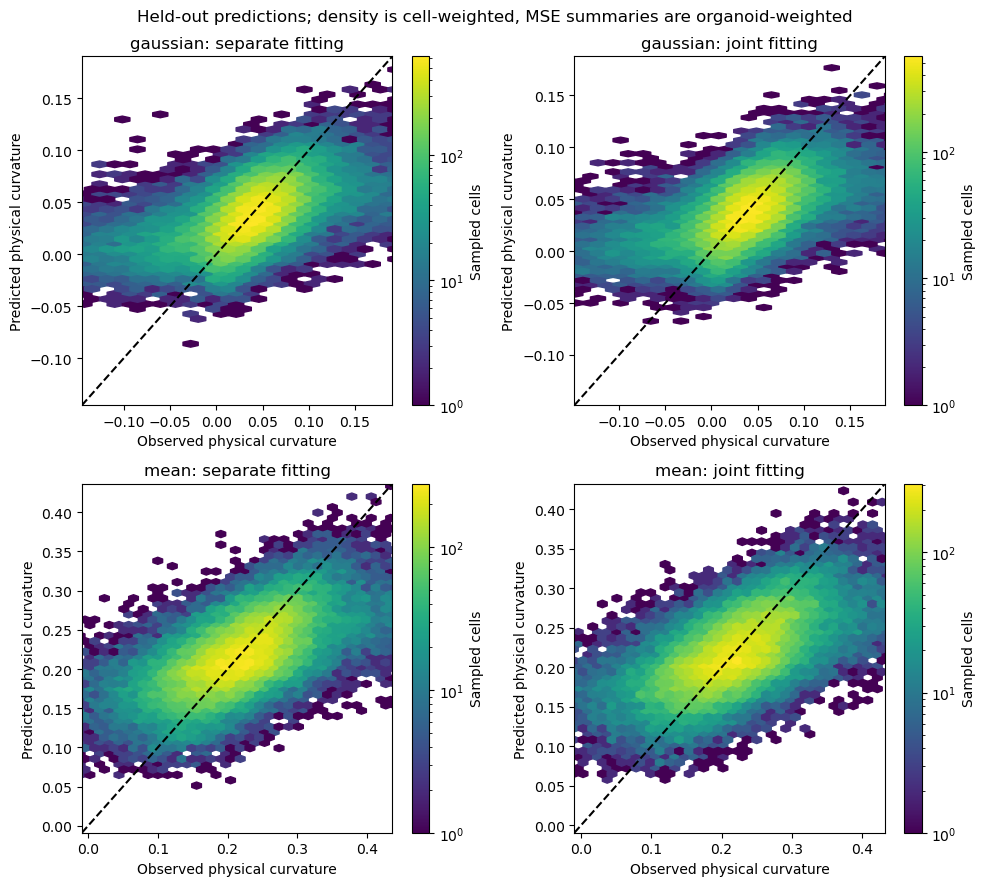

In [8]:
# Display actual held-out predictions from the prespecified N-dependent coupled models.
fig,axes=plt.subplots(2,2,figsize=(10,9))
rng=np.random.default_rng(42)
for target,individual in enumerate(['gaussian','mean']):
    for col,target_set in enumerate([individual,'joint']):
        name=f'{target_set}_learned_N_coupled'
        pieces=[]
        for row in records[records.name==name].itertuples():
            with np.load(OUTPUT_DIR/'predictions'/f'{row.key}.npz') as data:
                j=list(data['target_indices']).index(target)
                pieces.append(np.c_[data['truth'][:,j],data['prediction'][:,j]])
        values=np.concatenate(pieces)
        values=values[rng.choice(len(values),min(40000,len(values)),replace=False)]
        ax=axes[target,col];density=ax.hexbin(values[:,0],values[:,1],gridsize=50,mincnt=1,bins='log')
        lo,hi=np.quantile(values,[.005,.995]);ax.plot([lo,hi],[lo,hi],'k--');ax.set_xlim(lo,hi);ax.set_ylim(lo,hi)
        ax.set(xlabel='Observed physical curvature',ylabel='Predicted physical curvature',title=f'{individual}: {"joint" if col else "separate"} fitting')
        fig.colorbar(density,ax=ax,label='Sampled cells')
fig.suptitle('Held-out predictions; density is cell-weighted, MSE summaries are organoid-weighted')
fig.tight_layout();fig.savefig(OUTPUT_DIR/'prediction_comparison.png',dpi=160);plt.show()


## Propagation and patch-curvature consistency
Plot target-specific coupling and compare the descriptive H²−K diagnostic in predictions and observed patch averages. Patch averaging can itself produce negative values, so no hard geometric constraint is applied.

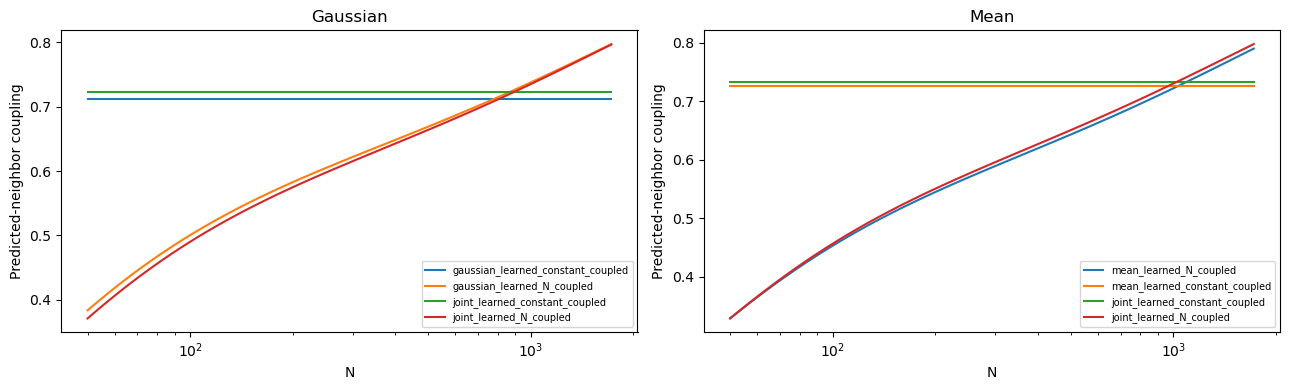

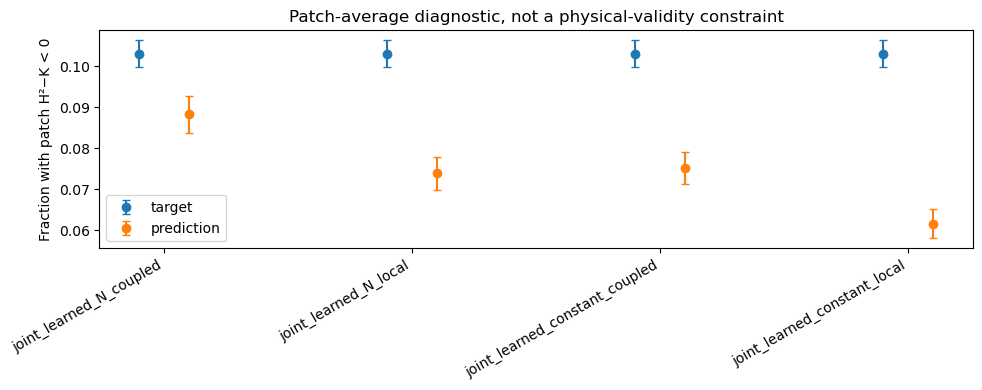

Evaluation artifacts: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/coupled_fate_training/activation_curvatures_20260928_170831/analysis/response_curvatures


In [9]:
fig,axes=plt.subplots(1,2,figsize=(13,4))
curves=pd.DataFrame(coupling_rows)
for target,ax in enumerate(axes):
    for name in curves.name.unique():
        if name.endswith('_local'):continue
        part=curves[(curves.name==name)&(curves.target==target)&(curves.fold==READOUT_FOLD)]
        if len(part):ax.plot(part.N,part.gamma,label=name)
    ax.set(xscale='log',xlabel='N',ylabel='Predicted-neighbor coupling',title=['Gaussian','Mean'][target]);ax.legend(fontsize=7)
fig.tight_layout();fig.savefig(OUTPUT_DIR/'coupling_vs_N.png',dpi=160);plt.show()

geo=pd.DataFrame(geometry)
fig,ax=plt.subplots(figsize=(10,4))
stats=geo.groupby(['name','kind']).fraction_below_zero.agg(['mean','sem']).reset_index()
for kind,offset in [('target',-.1),('prediction',.1)]:
    part=stats[stats.kind==kind]
    ax.errorbar(np.arange(len(part))+offset,part['mean'],yerr=part['sem'],fmt='o',capsize=3,label=kind)
ax.set_xticks(np.arange(len(part)),part.name,rotation=30,ha='right');ax.set(ylabel='Fraction with patch H²−K < 0',title='Patch-average diagnostic, not a physical-validity constraint');ax.legend()
fig.tight_layout();fig.savefig(OUTPUT_DIR/'patch_curvature_diagnostic.png',dpi=160);plt.show()
print('Evaluation artifacts:',OUTPUT_DIR)

## Numerical recovery check

Display the previously completed noiseless recovery check, when present in the selected run. It uses real outer-training graph layouts with planted coefficients; it tests numerical recovery under the model assumptions, not biological causality. No models are fitted here.

,start_gamma,start_alpha,true_gamma,fitted_gamma,heldout_mse,success,fallback,message,iterations,evaluations,objective,gradient_max,method,warm_start,median_abs_log_alpha_error
0,0.15,1.0,0.3,0.300381,1.380390e-08,True,False,Maximum number of iterations has been exceeded.,250,255,0.000002,8.620391e-07,preconditioned profile BFGS with smooth satura...,False,0.041179
1,0.55,8.0,0.3,0.299902,2.175205e-09,True,False,Maximum number of iterations has been exceeded.,250,252,0.000001,1.741460e-06,preconditioned profile BFGS with smooth satura...,False,0.026599


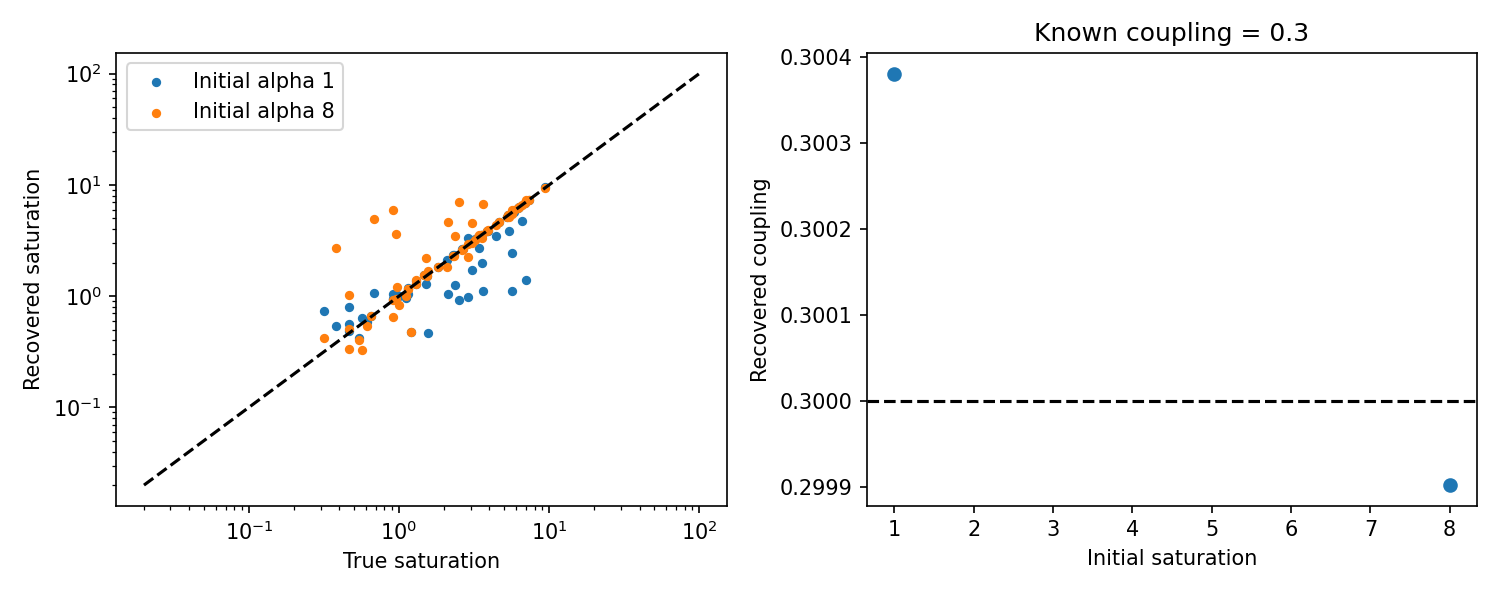

In [10]:
recovery_dir = run.directory/'diagnostics'
if (recovery_dir/'recovery_summary.csv').exists():
    display(pd.read_csv(recovery_dir/'recovery_summary.csv'))
    display(Image(filename=str(recovery_dir/'synthetic_recovery.png')))
else:
    print('No optional planted-model recovery diagnostic saved for this run.')

## Saved findings report

Summarize the held-out comparisons and parameter limitations in the run’s `REPORT.md`. Differences use paired organoid errors; their intervals condition on these fitted models. Mark evaluation complete only after all figures, tables and this report are saved.

In [11]:
total = summary[summary.region=='total'].set_index(['name','target'])
paired_table = pd.DataFrame(paired)
def reported_mse(name, target=0):
    return float(total.loc[(name,target),'mean'])
def reported_difference(model, reference_name, target=0):
    row = paired_table[(paired_table.model==model)&(paired_table.reference==reference_name)&(paired_table.target==target)].iloc[0]
    return f"{row.difference:+.3g} (conditional 95% CI {row.ci_low:+.3g} to {row.ci_high:+.3g})"

reference_mse = reported_mse('FiLM')
gaussian_rows = summary[(summary.region=='total')&(summary.target==0)&summary.name.str.startswith('gaussian_')]
best_gaussian = gaussian_rows.sort_values('mean').iloc[0]
main = 'gaussian_learned_N_coupled'
activation_table = ['| Activation | Constant, local | Constant, propagated | N-dependent, local | N-dependent, propagated |',
                    '| --- | ---: | ---: | ---: | ---: |']
for family in ['center','linear','fixed','learned']:
    values = [reported_mse(f'gaussian_{family}_{dep}_{mode}')*1000 for dep in ['constant','N'] for mode in ['local','coupled']]
    activation_table.append('| '+family+' | '+' | '.join(f'{value:.4f}' for value in values)+' |')
curvature_table = ['| Parameters / propagation | K separate | K joint | H separate | H joint |',
                   '| --- | ---: | ---: | ---: | ---: |']
for dep in ['constant','N']:
    for mode in ['local','coupled']:
        values = [reported_mse(f'gaussian_learned_{dep}_{mode}'),reported_mse(f'joint_learned_{dep}_{mode}'),
                  reported_mse(f'mean_learned_{dep}_{mode}',1),reported_mse(f'joint_learned_{dep}_{mode}',1)]
        curvature_table.append(f'| {dep} / {mode} | '+' | '.join(f'{1000*value:.4f}' for value in values)+' |')
selected_saturation = pd.DataFrame(saturation_rows)
selected_saturation = selected_saturation[(selected_saturation.name==main)&selected_saturation.fitted]
boundary_count = int(((selected_saturation.alpha<=.0201)|(selected_saturation.alpha>=99.)).sum())
stable_support = stability.reset_index()
stable_support = stable_support[(stable_support.name==main)&(stable_support.fitted_folds>=min(4,len(membership)))]
variable_count = int((stable_support.alpha_max/stable_support.alpha_min>10).sum())
recovery_path = run.directory/'diagnostics/recovery_summary.csv'
recovery_note = ''
if recovery_path.exists():
    recovery = pd.read_csv(recovery_path)
    recovered = ', '.join(f'{value:.5f}' for value in recovery.fitted_gamma)
    recovery_note = f' A noiseless planted-model check recovered known coupling 0.3 as {recovered}; this checks numerical recovery under the model assumptions.'
propagation_check = []
for row in records[records.name==main].itertuples():
    fitted_model = load_bundle(run.directory/row.bundle)['model']
    propagation_check.append(fitted_model.gamma(np.array([80.,700.]))[:,0])
propagation_check = np.asarray(propagation_check)
figures = OUTPUT_DIR.relative_to(run.directory).as_posix()
n_organoids = scores[(scores.target==0)&(scores.region=='total')].organoid_str.nunique()
report = f"""# Saturating fate interactions and curvature prediction

Completed **{len(records)} models across {len(membership)} saved folds**, evaluated on **{n_organoids} held-out organoids**. All predictions use fate, adjacency and (where enabled) N. Measured neighboring curvature is never an input. Global baselines are restored before evaluation.

## Main findings

The lowest Gaussian-only MSE is **{best_gaussian['mean']:.6f}** (`{best_gaussian['name']}`), versus **{reference_mse:.6f}** for the saved zero-mask depth-2 FiLM reference: **{100*(best_gaussian['mean']/reference_mse-1):+.2f}%** relative MSE. This is a descriptive ranking of the tested models, not independent confirmation of a selected winner.

For the prespecified N-dependent propagated model, paired MSE differences are:

- Learned versus linear activation: {reported_difference(main,'gaussian_linear_N_coupled')}.
- Learned versus fixed saturation: {reported_difference(main,'gaussian_fixed_N_coupled')}.
- Adding propagation to learned interactions: {reported_difference(main,'gaussian_learned_N_local')}.
- Adding N dependence to learned propagated interactions: {reported_difference(main,'gaussian_learned_constant_coupled')}.

For the N-dependent propagated models, learned saturation reduces MSE by {100*(1-reported_mse(main)/reported_mse('gaussian_linear_N_coupled')):.1f}% relative to linear activation. Adding propagation gives a further {100*(1-reported_mse(main)/reported_mse('gaussian_learned_N_local')):.1f}% reduction versus the local learned model. Adding N dependence gives {100*(1-reported_mse(main)/reported_mse('gaussian_learned_constant_coupled')):.1f}% versus its constant-parameter counterpart.

Negative differences favor the first model. Intervals condition on fitted models and do not include retraining uncertainty; the comparisons are exploratory.

## Gaussian-curvature comparison

Equal-organoid physical MSE ×10⁻³. Every local pair model uses radius two; propagation allows component-wide influence.

{chr(10).join(activation_table)}

## Separate versus joint curvature fitting

All entries are MSE ×10⁻³. **K and H have different physical units; compare methods within a column, not magnitudes across targets.** Joint fitting shares only pair saturation. Center preferences, amplitudes, propagation and baselines remain target-specific; fitting losses are scaled by training residual RMS and weighted equally.

{chr(10).join(curvature_table)}

For the N-dependent propagated models, joint minus separate MSE is {reported_difference('joint_learned_N_coupled',main)} for K and {reported_difference('joint_learned_N_coupled','mean_learned_N_coupled',1)} for H.

## Coefficients and interpretation

Propagation increases consistently with N: for the Gaussian learned model, gamma ranges across folds from **{propagation_check[:,0].min():.3f}–{propagation_check[:,0].max():.3f} at N=80** to **{propagation_check[:,1].min():.3f}–{propagation_check[:,1].max():.3f} at N=700**. This describes stronger smoothing in this fitted model; it does not measure tissue stiffness.

For `{main}`, **{boundary_count}/{len(selected_saturation)}** learned fold/pair saturation estimates approach a bound. Among pairs fitted in at least {min(4,len(membership))} folds, **{variable_count}/{len(stable_support)}** span more than tenfold in saturation. Read amplitudes and activation curves alongside their supported abundance ranges. Small amplitudes, limited source abundance and coefficient trade-offs can leave saturation poorly determined even with accurate predictions.{recovery_note}

Center preferences are local, baseline-relative quantities under the saved centering convention; they are not independently measured intrinsic cell curvature. Pair amplitudes change the local preference before propagation. Better prediction does not establish a mechanical mechanism or a causal cellular interaction.

## Model additions and comparability

The new response is `tanh(alpha*x)/tanh(alpha)`, with x the source fraction in the complete two-hop neighborhood. Hop amplitudes multiply the fraction of those source cells in each ring. All linear, fixed and learned controls use this construction. Fixed alpha=3 was specified before outer evaluation; learned alpha lies in [0.02,100], has weak shrinkage, and remains **constant across N**. N dependence applies to preferences, amplitudes and propagation. Pairs with insufficient fitting support retain fixed saturation.

Gaussian preprocessing and baselines match the original FiLM reference, including its historical target cleanup. Mean-curvature cleanup and baselines are fitted on the same outer-training organoids and frozen for their validation data. Inner selection conditions on this outer-training preprocessing. Constant local models still use the same size-dependent global baseline. FiLM is an accuracy reference with its original loss and different effective reach.

The source stores cell-patch averaged K and H. Consequently H_patch²−K_patch is a descriptive diagnostic, not a pointwise physical constraint. Numerical preconditioning and warm starts change the optimizer, not the statistical objective. Saved fits pass the fitter's projected-gradient acceptance check.

## Figures and artifacts

- [Activation, propagation and N comparison]({figures}/gaussian_activation_comparison.png).
- [Separate versus joint targets]({figures}/separate_vs_joint.png) and [held-out prediction plots]({figures}/prediction_comparison.png).
- [Regional MSE]({figures}/mse_by_region.png) and [MSE versus N]({figures}/mse_by_size.png).
- [Center preferences]({figures}/center_preferences.png), [propagation]({figures}/coupling_vs_N.png), and [supported activation curves]({figures}/activation_support.png).

The notebook also displays all-pair amplitude and saturation figures for the selected target/fold and both size settings. All learned-model coefficients, support, node predictions, organoid scores and paired comparisons are exported beside the figures. Change the readout settings to inspect other targets or folds without refitting. The earlier completed experiment remains unchanged.
"""
(run.directory/'REPORT.md').write_text(report)
(OUTPUT_DIR/'complete.json').write_text(json.dumps(dict(models=len(records),evaluations=len(audits),report='REPORT.md'),indent=2))
print('Report:',run.directory/'REPORT.md')


Report: /home/fmoller/Projects/LearningOrganoids/GraphNN/training_results/coupled_fate_training/activation_curvatures_20260928_170831/REPORT.md
